In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
# --- 1. Data Preparation ---
df = pd.read_csv('Zoo.csv')
X = df.drop(['animal name', 'type'], axis=1) # Drop non-numeric identifier and target
y = df['type']

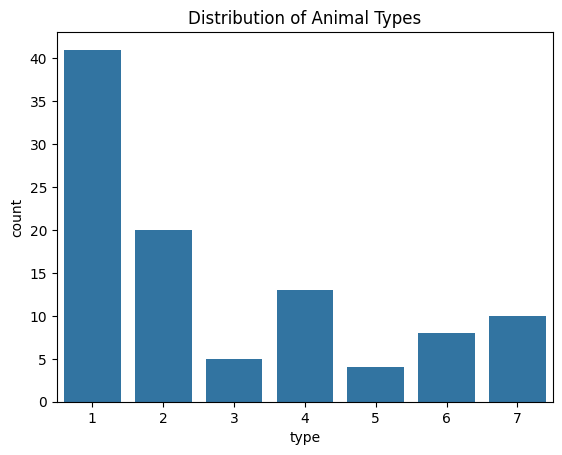

In [5]:
# Visualize target distribution
sns.countplot(x='type', data=df)
plt.title('Distribution of Animal Types')
plt.show()

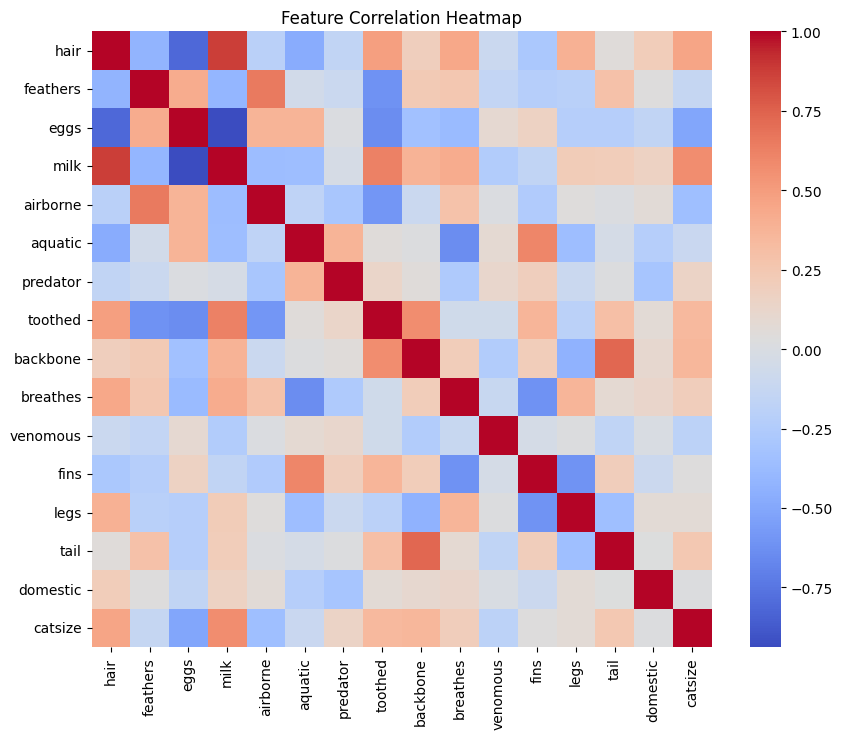

In [6]:
# Visualize correlation
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

In [7]:
# Scaling: Essential for distance-based algorithms like KNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [9]:
# Search for optimal K and distance metric
param_grid = {'n_neighbors': np.arange(1, 20), 'metric': ['euclidean', 'manhattan']}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print(f"Optimal Hyperparameters: {grid.best_params_}")
best_knn = grid.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Optimal Hyperparameters: {'metric': 'euclidean', 'n_neighbors': np.int64(1)}


In [10]:
# --- Evaluation ---
y_pred = best_knn.predict(X_test)
print("\nEvaluation Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))



Evaluation Metrics:
Accuracy: 1.0000

Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [11]:
# Using PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_train_pca, _, y_train_pca, _ = train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [12]:
knn_pca = KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'], metric=grid.best_params_['metric'])
knn_pca.fit(X_train_pca, y_train_pca)

KNeighborsClassifier(metric='euclidean', n_neighbors=np.int64(1))